In [39]:
from tokenize import PlainToken

import numpy as np
import pandas as pd

from sklearn.datasets import make_classification

from SCIKIT.Lesson21GradientBoostingClassification import y_probability, y_test

from SCIKIT.Lesson22Xgboosting import y_val
from torch.nn.functional import threshold

X, y = make_classification(
    n_samples=3000,
    n_features=15,
    n_informative=9,
    n_redundant=3,
    n_classes=2,
    weights=[0.55, 0.45],
    class_sep=1.15,
    flip_y=0.03,
    random_state=42
)

feature_names = [
    "income",
    "credit_score",
    "loan_amount",
    "employment_years",
    "debt_ratio",
    "savings",
    "age",
    "dependents",
    "assets",
    "financial_history",
    "risk_score",
    "payment_history",
    "loan_term",
    "account_age",
    "income_stability"
]

X = pd.DataFrame(
    X,
    columns=feature_names
)

y = pd.Series(
    y,
    name="loan_status"
)

print(X.shape)
print(y.value_counts())
X.head()


ModuleNotFoundError: No module named 'SCIKIT.Lesson21GradientBoostingClassification'

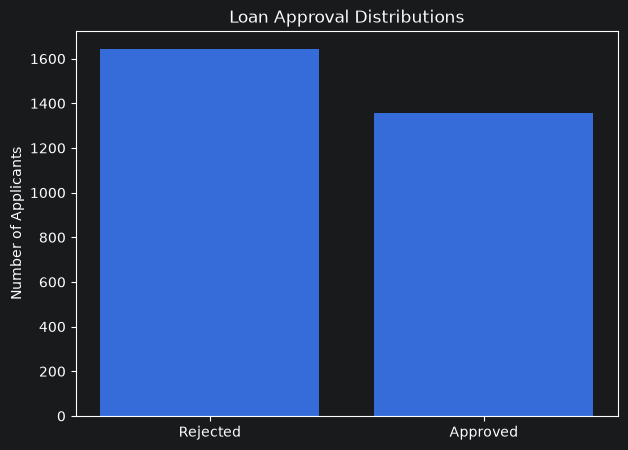

In [7]:
import matplotlib.pyplot as plt
counts=y.value_counts().sort_index()

plt.figure(figsize=(7,5))
plt.bar(["Rejected","Approved"],counts.values)
plt.ylabel("Number of Applicants")
plt.title("Loan Approval Distributions")
plt.show()


In [20]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (1536, 15)
Validation: (384, 15)
Test: (600, 15)


In [38]:
from xgboost import XGBClassifier

xgb_classifier = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    early_stopping_rounds=50,
    random_state=42
)

In [45]:
xgb_classifier.fit(
    X_train,
    y_train,

    eval_set=[
        (X_train, y_train),
        (X_val, y_val)
    ],

    verbose=False
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [46]:
print("Best iteration",
      xgb_classifier.best_iteration)
print("Best validation score",
      xgb_classifier.best_score)

Best iteration 375
Best validation score 0.21283450174041718


In [47]:
y_pred = xgb_classifier.predict(X_val)
y_probability = xgb_classifier.predict_proba(X_val)[:, 1]

accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
auc = roc_auc_score(y_val, y_probability)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")


Accuracy : 0.9193
Precision: 0.9281
Recall   : 0.8908
F1 Score : 0.9091
ROC-AUC  : 0.9667


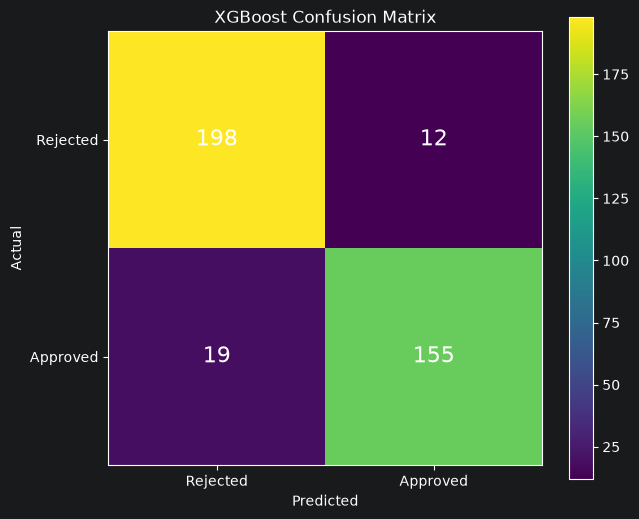

In [53]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_val,
    y_pred
)

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    [0, 1],
    ["Rejected", "Approved"]
)

plt.yticks(
    [0, 1],
    ["Rejected", "Approved"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("XGBoost Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=16
        )

plt.show()

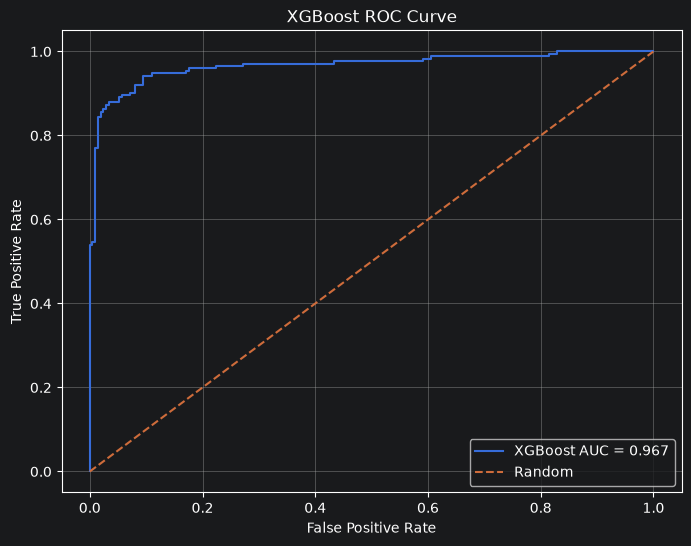

In [56]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_val,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost AUC = {auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("XGBoost ROC Curve")

plt.legend()
plt.grid()

plt.show()

In [57]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_classifier.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

print(importance_df)

              Feature  Importance
1        credit_score    0.210201
2         loan_amount    0.109232
8              assets    0.102761
0              income    0.089206
12          loan_term    0.068137
13        account_age    0.065461
14   income_stability    0.063687
6                 age    0.051063
3    employment_years    0.050557
5             savings    0.046581
9   financial_history    0.040514
11    payment_history    0.038682
4          debt_ratio    0.021408
10         risk_score    0.021300
7          dependents    0.021210


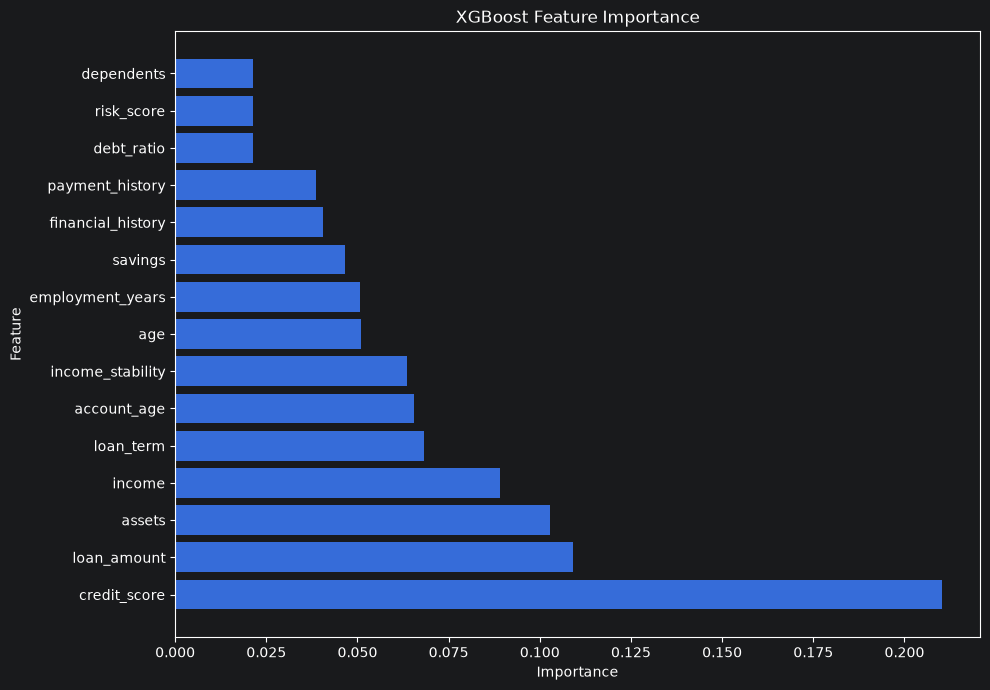

In [58]:
plt.figure(figsize=(10, 7))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "XGBoost Feature Importance"
)

plt.tight_layout()

plt.show()

In [60]:
thresholds = np.arange(
    0.10,
    0.91,
    0.01
)

f1_scores = []

for threshold in thresholds:

    predictions = (
        y_probability >= threshold
    ).astype(int)

    score = f1_score(
        y_val,
        predictions,
        zero_division=0
    )

    f1_scores.append(score)

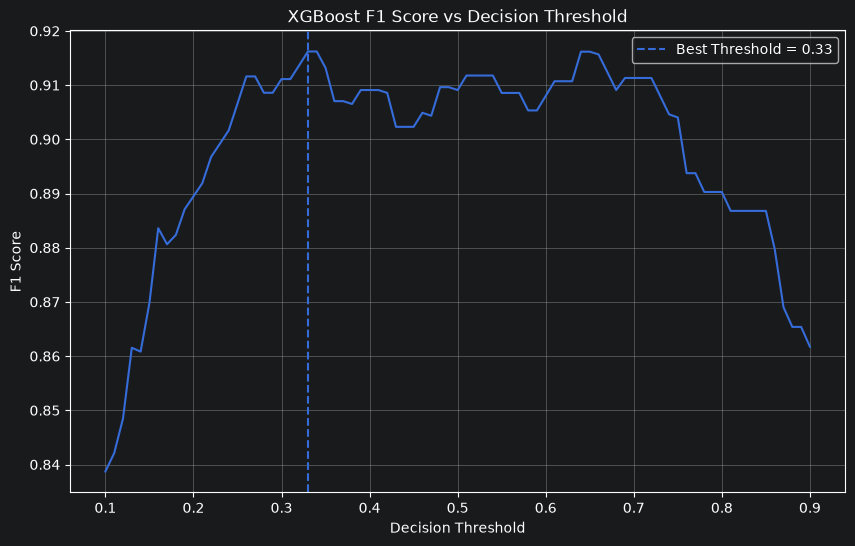

In [61]:
plt.figure(figsize=(10, 6))

plt.plot(
    thresholds,
    f1_scores
)

best_index = np.argmax(f1_scores)

plt.axvline(
    thresholds[best_index],
    linestyle="--",
    label=f"Best Threshold = {thresholds[best_index]:.2f}"
)

plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")

plt.title(
    "XGBoost F1 Score vs Decision Threshold"
)

plt.legend()
plt.grid()

plt.show()

In [62]:
%pip install shap

   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/43.0 MB ? eta -:--:--
    --------------------------------------- 0.8/43.0 MB 2.2 MB/s eta 0:00:20
    --------------------------------------- 1.0/43.0 MB 1.9 MB/s eta 0:00:23
   - -------------------------------------- 1.6/43.0 MB 2.0 MB/s eta 0:00:21
   - -------------------------------------- 1.8/43.0 MB 2.0 MB/s eta 0:00:21
   -- ------------------------------------- 2.4/43.0 MB 2.0 MB/s eta 0:00:21
   -- ------------------------------------- 2.9/43.0 MB 2.0 MB/s eta 0:00:20
   -- ------------------------------------- 3.1/43.0 MB 2.1 MB/s eta 0:00:19
   --- ------------------------------------ 3.7/43.0 MB 2.1 MB/s eta 0:00:19
   ---- ----------------------------------- 4.5/43.0 MB 2.2 MB/s eta 0:00:18
   ---- ----------------------------------- 5.0/43.0 MB 2.3 MB/s eta 0:00:17
   ---- ----------------------------------- 5.2/43.0 MB 2.1 MB/s eta 0:00:18
   ----- ----

In [63]:
import shap

In [65]:
explainer=shap.TreeExplainer(xgb_classifier)
explainer

In [66]:
shap_values = explainer.shap_values(
    X_test
)

In [67]:
print(
    "SHAP shape:",
    np.array(shap_values).shape
)

SHAP shape: (600, 15)


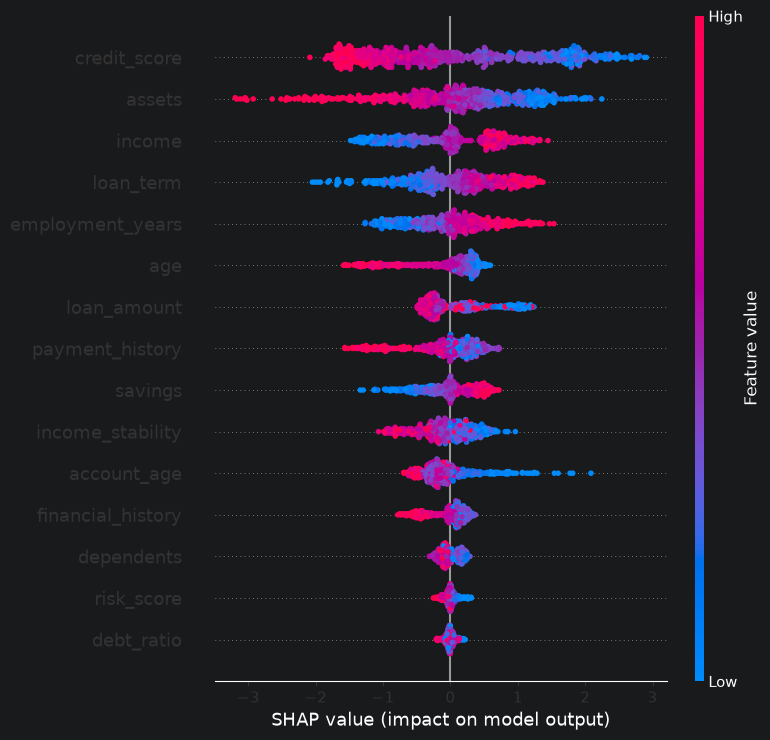

In [68]:
shap.summary_plot(
    shap_values,
    X_test
)

In [69]:
shap_importance = np.abs(
    shap_values
).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP Importance": shap_importance
})

shap_importance_df = (
    shap_importance_df
    .sort_values(
        "SHAP Importance",
        ascending=False
    )
)

print(shap_importance_df)

              Feature  SHAP Importance
1        credit_score         1.105222
8              assets         0.793196
0              income         0.587561
12          loan_term         0.554424
3    employment_years         0.443636
6                 age         0.397840
2         loan_amount         0.363306
11    payment_history         0.334641
5             savings         0.306963
14   income_stability         0.299819
13        account_age         0.284368
9   financial_history         0.193791
7          dependents         0.114415
10         risk_score         0.054599
4          debt_ratio         0.045673


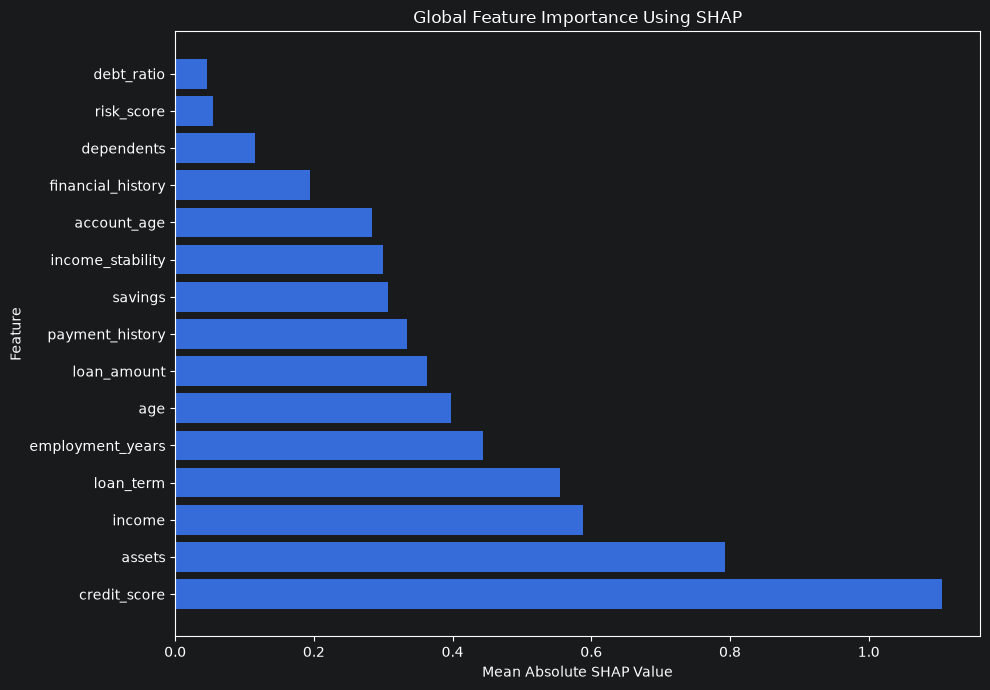

In [70]:
plt.figure(figsize=(10, 7))

plt.barh(
    shap_importance_df["Feature"],
    shap_importance_df["SHAP Importance"]
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel("Feature")

plt.title(
    "Global Feature Importance Using SHAP"
)

plt.tight_layout()

plt.show()

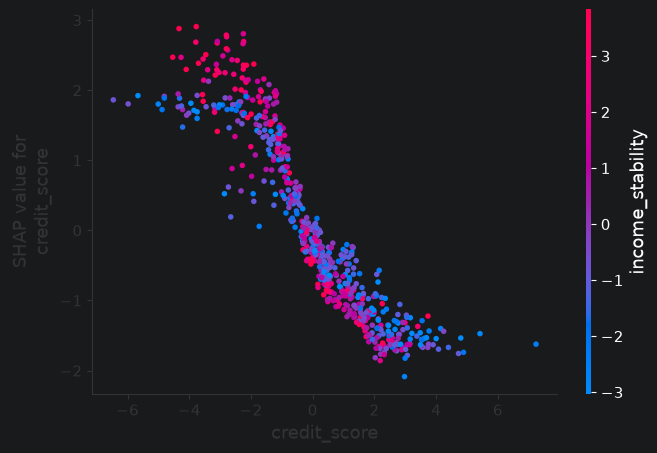

In [71]:
shap.dependence_plot(
    "credit_score",
    shap_values,
    X_test
)


In [72]:
sample_index = 10

sample = X_test.iloc[
    sample_index
]

print(sample)

income              -3.044809
credit_score         1.249696
loan_amount         -1.009796
employment_years     2.346569
debt_ratio           1.335452
savings             -0.051047
age                  2.305633
dependents           0.783984
assets              -0.295094
financial_history   -0.843720
risk_score          -0.605517
payment_history      1.875544
loan_term           -1.165389
account_age         -1.320174
income_stability    -2.147438
Name: 461, dtype: float64


In [73]:
sample_probability = (
    xgb_classifier
    .predict_proba(
        sample.to_frame().T
    )[0, 1]
)

print(
    "Approval probability:",
    sample_probability
)

Approval probability: 0.3773595


In [74]:
sample_probability = (
    xgb_classifier
    .predict_proba(
        sample.to_frame().T
    )[0, 1]
)

print(
    "Approval probability:",
    sample_probability
)

Approval probability: 0.3773595


In [75]:
sample_shap = shap_values[
    sample_index
]


In [76]:
individual_explanation = pd.DataFrame({
    "Feature": X_test.columns,
    "Value": sample.values,
    "SHAP Value": sample_shap
})

individual_explanation = (
    individual_explanation
    .sort_values(
        "SHAP Value",
        key=abs,
        ascending=False
    )
)

individual_explanation

,Feature,Value,SHAP Value
0,income,-3.044809,-1.074986
8,assets,-0.295094,0.848225
6,age,2.305633,-0.384291
3,employment_years,2.346569,0.367911
1,credit_score,1.249696,-0.326507
14,income_stability,-2.147438,0.293291
13,account_age,-1.320174,-0.282267
5,savings,-0.051047,0.228806
12,loan_term,-1.165389,-0.156594
9,financial_history,-0.843720,0.146103


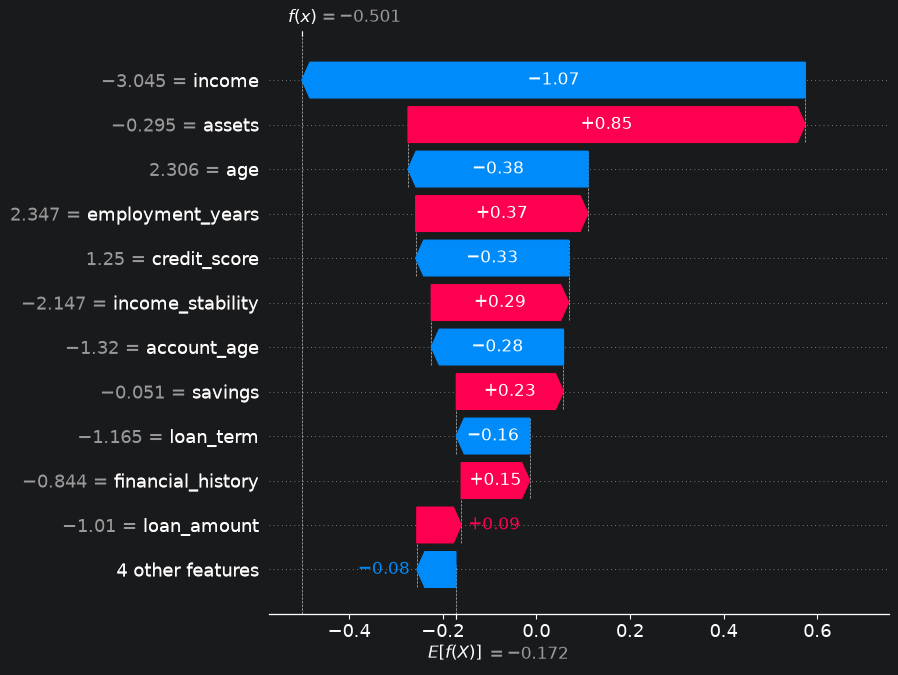

In [77]:
explanation = shap.Explanation(
    values=sample_shap,
    base_values=explainer.expected_value,
    data=sample.values,
    feature_names=X_test.columns
)

shap.plots.waterfall(
    explanation,
    max_display=12
)